## EDA ##

In [71]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [72]:
df= pd.read_csv(r"C:\Users\Shubham2\Downloads\machine learning model\Project Files\Customer_support_data.csv")

In [73]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [74]:
df.sample(5,random_state=41)

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
62685,58fb7021-6550-417c-85e9-808e06ec3ca4,Inbound,Order Related,Order status enquiry,NaN,f0005666-c0a4-460b-a5e7-eba052d3a043,NaN,24/08/2023 19:53,24/08/2023 19:54,24-Aug-23,NaN,NaN,NaN,NaN,James Duncan,Olivia Suzuki,Jennifer Nguyen,On Job Training,Morning,4
46629,b0f7e2eb-ef78-449a-87bc-d644b2960941,Inbound,Order Related,Invoice request,NaN,801e0b27-85d7-4ee9-ac76-126c5ad43ffd,NaN,19/08/2023 08:16,19/08/2023 08:17,19-Aug-23,NaN,NaN,NaN,NaN,Kimberly Medina,Lily Chen,Michael Lee,>90,Morning,5
17963,957518de-7514-467c-9279-28041669e1ca,Inbound,Returns,Missing,NaN,dcaf9c66-6740-4dcf-88a2-284fc815b596,NaN,08/08/2023 16:26,08/08/2023 17:40,08-Aug-23,NaN,NaN,NaN,NaN,Joshua Day,Emily Yamashita,Olivia Tan,>90,Morning,4
85421,e5d4ee03-85ff-4299-aa92-5d53c4df889a,Outcall,Order Related,Order status enquiry,Nicely behaviour,a4c38c7e-e6b8-48c5-962f-5952a78dd853,NaN,31/08/2023 15:49,31/08/2023 15:54,31-Aug-23,NaN,NaN,NaN,NaN,Sharon Stephenson,Jacob Sato,Emily Chen,0-30,Evening,5
30844,cd5f78db-5ec3-4daf-ab13-581bf493495a,Inbound,Returns,Reverse Pickup Enquiry,It is my sincere request to Shopzilla team don...,a8f24b60-8b57-440d-a31d-96fe6eb6f813,05/08/2023 17:45,11/08/2023 22:08,11/08/2023 22:12,11-Aug-23,DHENKANAL,LifeStyle,231.0,NaN,Samantha Miller,Brayden Wong,John Smith,>90,Evening,5


In [75]:
df.shape

(85907, 20)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [77]:
df.isnull().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

In [78]:
df.describe().round(2)

,Item_price,connected_handling_time,CSAT Score
count,17206.00,242.00,85907.00
mean,5660.77,462.40,4.24
std,12825.73,246.30,1.38
min,0.00,0.00,1.00
25%,392.00,293.00,4.00
50%,979.00,427.00,5.00
75%,2699.75,592.25,5.00
max,164999.00,1986.00,5.00


In [79]:
df.describe(include='object')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,85907,85907,85907,85907,85907
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,1371,40,6,5,5
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,15/08/2023 10:59,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,Wendy Taylor,Carter Park,John Smith,>90,Morning
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,429,4273,25261,30660,41426


In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
unq=['channel_name', 'category', 'Sub-category','Survey_response_Date','Product_category', 'Tenure Bucket']
for i in unq:
    print(f"\n {i}: ")
    print(df[i].unique())


 channel_name: 
['Outcall' 'Inbound' 'Email']

 category: 
['Product Queries' 'Order Related' 'Returns' 'Cancellation'
 'Shopzilla Related' 'Payments related' 'Refund Related' 'Feedback'
 'Offers & Cashback' 'Onboarding related' 'Others' 'App/website']

 Sub-category: 
['Life Insurance' 'Product Specific Information' 'Installation/demo'
 'Reverse Pickup Enquiry' 'Not Needed' 'Fraudulent User'
 'Exchange / Replacement' 'Missing' 'General Enquiry' 'Return request'
 'Delayed' 'Service Centres Related' 'Payment related Queries'
 'Order status enquiry' 'Return cancellation' 'Unable to track'
 'Seller Cancelled Order' 'Wrong' 'Invoice request' 'Priority delivery'
 'Refund Related Issues' 'Signup Issues' 'Online Payment Issues'
 'Technician Visit' 'UnProfessional Behaviour' 'Damaged'
 'Product related Issues' 'Refund Enquiry'
 'Customer Requested Modifications' 'Instant discount' 'Card/EMI'
 'Shopzila Premium Related' 'Account updation' 'COD Refund Details'
 'Seller onboarding' 'Order Verifi

In [82]:
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [83]:
num_columns= ['Item_price', 'connected_handling_time','CSAT Score']

In [84]:
df_eda = pd.read_csv(r"C:\Users\Shubham2\Downloads\machine learning model\Project Files\Customer_support_data.csv")

In [85]:
print(df_eda.columns.tolist())

['Unique id', 'channel_name', 'category', 'Sub-category', 'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date', 'Customer_City', 'Product_category', 'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score']


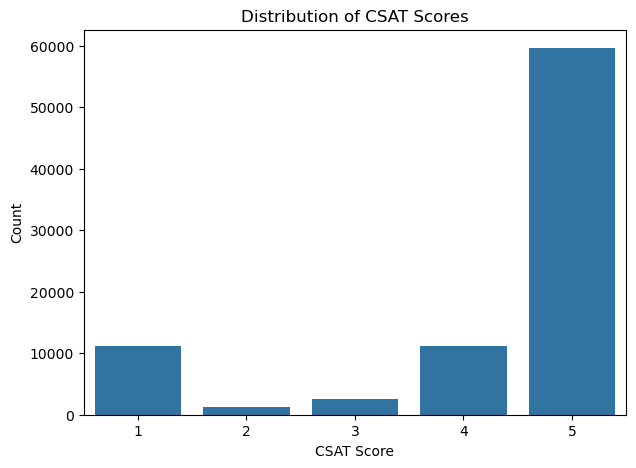

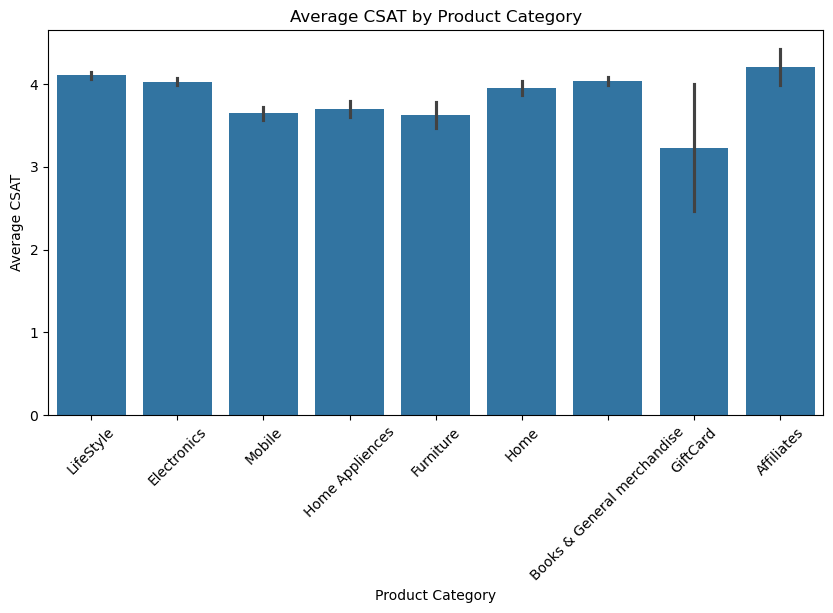

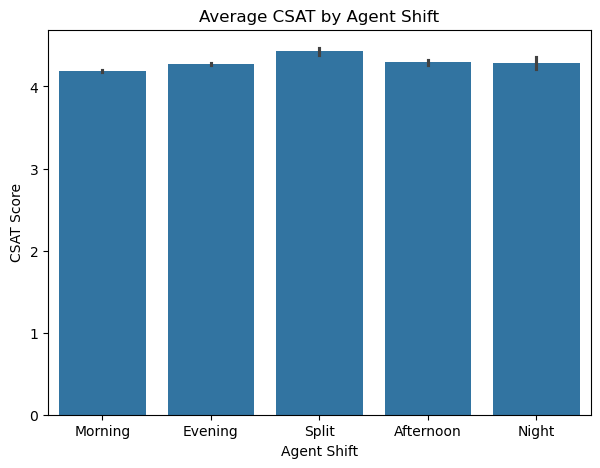

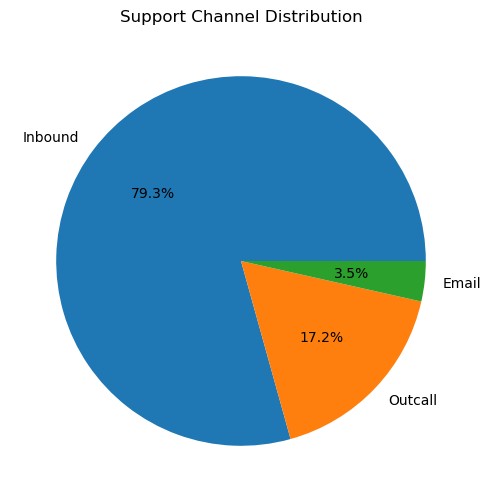

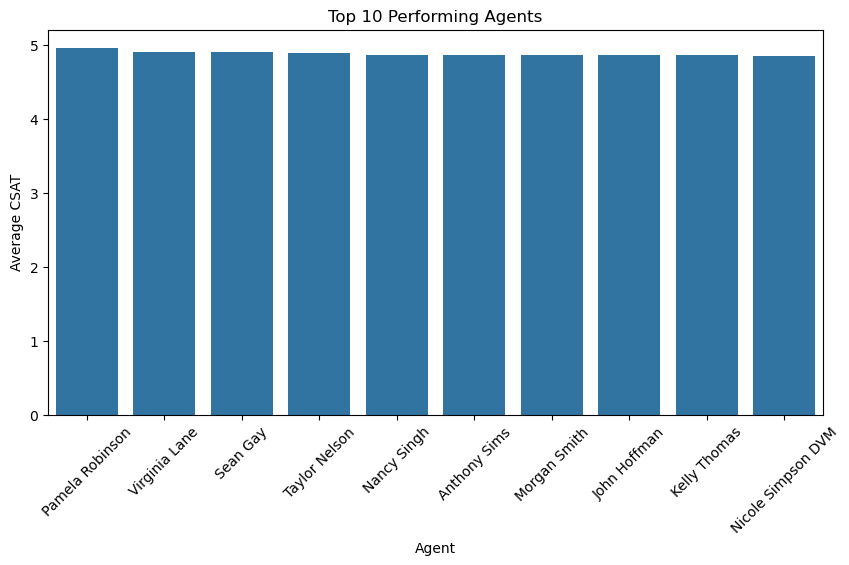

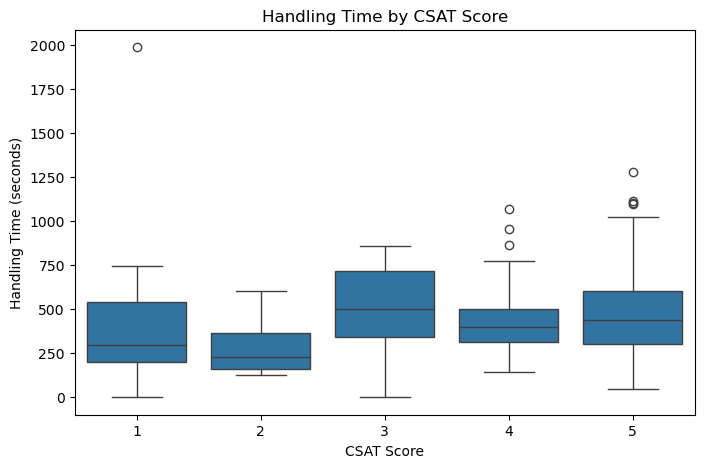

In [86]:
# 1. CSAT Score Distribution
plt.figure(figsize=(7,5))
sns.countplot(data=df_eda, x='CSAT Score')
plt.title("Distribution of CSAT Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")
plt.show()
# 2. Average CSAT by Product Category
plt.figure(figsize=(10,5))
sns.barplot(data=df_eda,x='Product_category',y='CSAT Score',estimator='mean')
plt.xticks(rotation=45)
plt.title("Average CSAT by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average CSAT")
plt.show()
# 3. Average CSAT by Shift
plt.figure(figsize=(7,5))
sns.barplot(data=df_eda,x='Agent Shift',y='CSAT Score')
plt.title("Average CSAT by Agent Shift")
plt.show()
# 4. Support Channel Distribution
plt.figure(figsize=(6,6))
df_eda['channel_name'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.ylabel('')
plt.title('Support Channel Distribution')
plt.show()
# 5. Top 10 Performing Agents
top_agents = (df_eda.groupby('Agent_name')['CSAT Score'].mean().sort_values(ascending=False).head(10))
plt.figure(figsize=(10,5))
sns.barplot(x=top_agents.index,y=top_agents.values)
plt.xticks(rotation=45)
plt.title("Top 10 Performing Agents")
plt.xlabel("Agent")
plt.ylabel("Average CSAT")
plt.show()
#6. Handling Time by CSAT Score
plt.figure(figsize=(8,5))
sns.boxplot(data=df_eda,x='CSAT Score',y='connected_handling_time')
plt.title("Handling Time by CSAT Score")
plt.xlabel("CSAT Score")
plt.ylabel("Handling Time (seconds)")
plt.show()

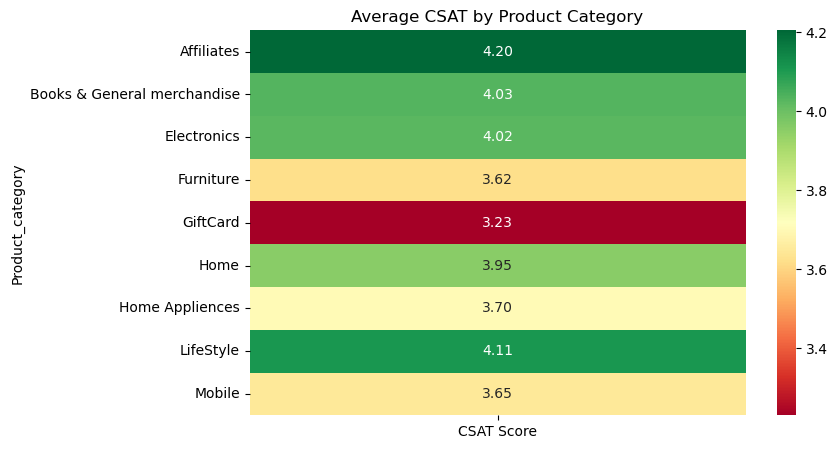

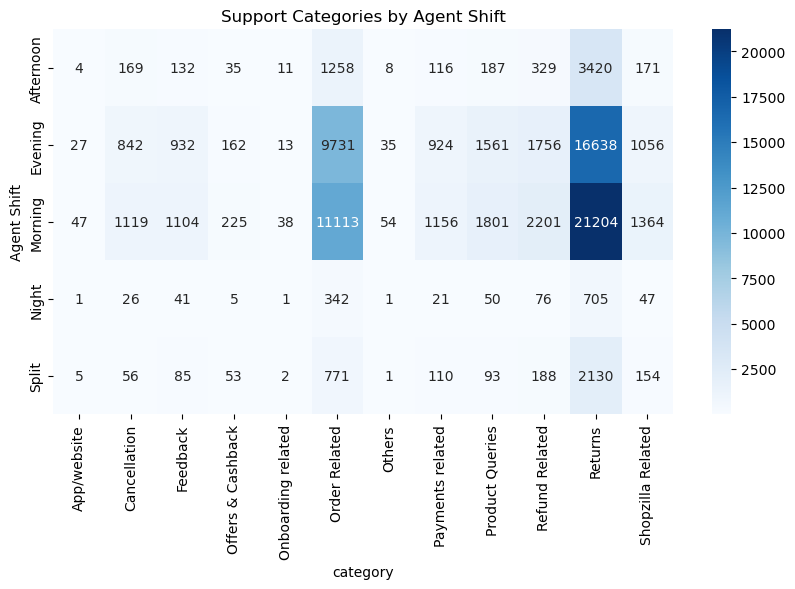

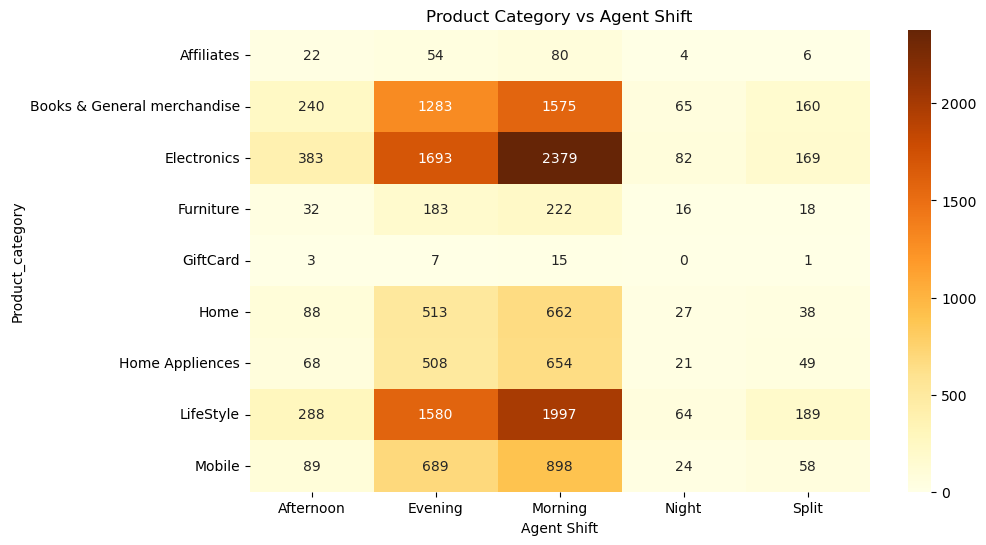

In [87]:
pivot = df.pivot_table(
    values='CSAT Score',
    index='Product_category',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap='RdYlGn',
    fmt='.2f'
)

plt.title("Average CSAT by Product Category")
plt.show()

pivot = pd.crosstab(
    df['Agent Shift'],
    df['category']
)

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title("Support Categories by Agent Shift")
plt.show()

pivot = df.pivot_table(
    values='CSAT Score',
    index='Customer_City',
    aggfunc='mean'
)

pivot = df.pivot_table(
    values='CSAT Score',
    index='Supervisor',
    aggfunc='mean'
)

pivot = pd.crosstab(
    df['Product_category'],
    df['Agent Shift']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlOrBr',
    fmt='d'
)

plt.title("Product Category vs Agent Shift")
plt.show()

## Data Cleanup ##

In [88]:
## Identifying all null values first
df.isnull().sum()



Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

In [89]:
""" Because there are just null values in 7 columns we will just replace null/blank values there
with mean,median for int,float and mode for objects """
##using median because time and prices are often skewed
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    df[col] = df[col].fillna(df[col].median())
# For objects
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,HYDERABAD,Electronics,979.0,427.0,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,Good,d406b0c7-ce17-4654-b9de-f08d421254bd,09/08/2023 11:55,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,HYDERABAD,Electronics,979.0,427.0,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,Good,c273368d-b961-44cb-beaf-62d6fd6c00d5,09/08/2023 11:55,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,HYDERABAD,Electronics,979.0,427.0,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,Good,5aed0059-55a4-4ec6-bb54-97942092020a,09/08/2023 11:55,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,HYDERABAD,Electronics,979.0,427.0,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,Good,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,09/08/2023 11:55,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,HYDERABAD,Electronics,979.0,427.0,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [90]:
df.isnull().sum()

Unique id                  0
channel_name               0
category                   0
Sub-category               0
Customer Remarks           0
Order_id                   0
order_date_time            0
Issue_reported at          0
issue_responded            0
Survey_response_Date       0
Customer_City              0
Product_category           0
Item_price                 0
connected_handling_time    0
Agent_name                 0
Supervisor                 0
Manager                    0
Tenure Bucket              0
Agent Shift                0
CSAT Score                 0
dtype: int64

In [91]:
# Check for invalid values

print("Negative Item Price")
display(df[df['Item_price'] < 0][['Product_category', 'Item_price']])

print("Negative Handling Time")
display(df[df['connected_handling_time'] < 0][['category', 'connected_handling_time']])

print("Invalid CSAT Score")
display(df[(df['CSAT Score'] < 1) | (df['CSAT Score'] > 5)]
        [['Agent_name', 'CSAT Score']])


# Highest Item Prices
print("Top 10 Highest Item Prices")
display(df[['Product_category', 'Sub-category', 'Item_price']]
        .sort_values(by='Item_price', ascending=False)
        .head(10))

print("Top 10 lowest Item Prices")
display(df[['Product_category', 'Sub-category', 'Item_price']]
        .sort_values(by='Item_price', ascending=True)
        .head(10))


# Longest Handling Time
print("Top 10 Longest Handling Time")
display(df[['connected_handling_time', 'category', 'Product_category', 'CSAT Score']]
        .sort_values(by='connected_handling_time', ascending=False)
        .head(10))

print("Top 10 Shortest Handling Time")
display(df[['connected_handling_time', 'category', 'Product_category', 'CSAT Score']]
        .sort_values(by='connected_handling_time', ascending=True)
        .head(10))



Negative Item Price


,Product_category,Item_price


Negative Handling Time


,category,connected_handling_time


Invalid CSAT Score


,Agent_name,CSAT Score


Top 10 Highest Item Prices


,Product_category,Sub-category,Item_price
56000,Mobile,Delayed,164999.0
46357,Electronics,Technician Visit,159990.0
67099,Electronics,Technician Visit,151990.0
84340,Electronics,Delayed,144990.0
7582,Mobile,Reverse Pickup Enquiry,134999.0
14247,Electronics,Order status enquiry,134990.0
15698,Electronics,Order status enquiry,134990.0
66695,Mobile,Damaged,129999.0
37291,Mobile,UnProfessional Behaviour,127999.0
14758,Mobile,Order status enquiry,127999.0


Top 10 lowest Item Prices


,Product_category,Sub-category,Item_price
32198,Books & General merchandise,Refund Related Issues,0.0
25148,Electronics,Reverse Pickup Enquiry,1.0
26236,Electronics,General Enquiry,1.0
22600,Electronics,Wallet related,1.0
24850,Electronics,General Enquiry,1.0
82124,Electronics,General Enquiry,1.0
31458,Electronics,General Enquiry,1.0
38700,Electronics,Order status enquiry,1.0
28278,Electronics,General Enquiry,1.0
32759,Electronics,General Enquiry,1.0


Top 10 Longest Handling Time


,connected_handling_time,category,Product_category,CSAT Score
30465,1986.0,Refund Related,Mobile,1
39524,1277.0,Returns,Electronics,5
12538,1115.0,Cancellation,Electronics,5
56567,1100.0,Payments related,Electronics,5
40041,1094.0,Cancellation,Electronics,5
12722,1066.0,Cancellation,Electronics,4
50910,1025.0,Returns,Electronics,5
13798,987.0,Cancellation,Electronics,5
35471,980.0,Returns,Electronics,5
41184,962.0,Returns,Electronics,5


Top 10 Shortest Handling Time


,connected_handling_time,category,Product_category,CSAT Score
36243,0.0,Cancellation,Electronics,3
8501,0.0,Shopzilla Related,Electronics,1
46703,45.0,Returns,Electronics,5
68665,63.0,Order Related,Electronics,5
21130,72.0,Order Related,Electronics,5
21059,124.0,Order Related,Electronics,5
18351,125.0,Order Related,Electronics,2
17517,141.0,Returns,Electronics,1
19355,142.0,Returns,Electronics,4
11864,153.0,Order Related,Electronics,5


In [92]:
## we found oultlier and that is no item can price as 0 rupee
df[df['Item_price'] == 0].shape[0]

1

In [93]:
## Replace the value with median
df.loc[df['Item_price'] == 0, 'Item_price'] = df['Item_price'].median()

In [94]:
display(df[['Item_price']].sort_values(by='Item_price', ascending=True).head(10))

,Item_price
22600,1.0
24850,1.0
47683,1.0
31458,1.0
82124,1.0
18902,1.0
38700,1.0
27728,1.0
25148,1.0
59793,1.0


In [95]:
# Check categorical columns

print("Product Category")
print(df['Product_category'].value_counts())

print("\nCustomer City")
print(df['Customer_City'].value_counts())

print("\nAgent Shift")
print(df['Agent Shift'].value_counts())

print("\nChannel Name")
print(df['channel_name'].value_counts())

print("\nTenure Bucket")
print(df['Tenure Bucket'].value_counts())

Product Category
Product_category
Electronics                    73417
LifeStyle                       4118
Books & General merchandise     3323
Mobile                          1758
Home                            1328
Home Appliences                 1300
Furniture                        471
Affiliates                       166
GiftCard                          26
Name: count, dtype: int64

Customer City
Customer_City
HYDERABAD    69550
NEW DELHI      688
PUNE           435
MUMBAI         406
BANGALORE      352
             ...  
GUNTAKAL         1
MANSAR           1
BAGHMARA         1
HINDORIA         1
DORAHA           1
Name: count, Length: 1782, dtype: int64

Agent Shift
Agent Shift
Morning      41426
Evening      33677
Afternoon     5840
Split         3648
Night         1316
Name: count, dtype: int64

Channel Name
channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64

Tenure Bucket
Tenure Bucket
>90                30660
On Job Training    25523


In [96]:
invalid_dates = df[df['Issue_reported at'] < df['order_date_time']]

print("Invalid records:", len(invalid_dates))
print("Percentage:", (len(invalid_dates) / len(df)) * 100)

Invalid records: 22055
Percentage: 25.673111620706113


In [97]:
df.drop(columns=['Days_to_Report'], inplace=True, errors='ignore')

## Feature Engineering ##

In [98]:
## converting seconds into minutes
df['handling_time_minutes'] = df['connected_handling_time'] / 60
## call more then particulat time
df['Long Call'] = df['connected_handling_time'] > 600
## Customer remark length for satisfaction counting as those who write more are less satisfied intuitively
df['Remark Length'] = df['Customer Remarks'].fillna('').str.len()
##Is complain return
df['Has Remarks'] = (df['Customer Remarks'].fillna('').str.strip() != '')
#peak shift
df['Peak Shift'] = df['Agent Shift'].isin(['Morning', 'Evening'])
#Expensive products
median_price = df['Item_price'].median(
df['Expensive Product'] = df['Item_price'] > median_price
#order_date_time
df['order_date_time'] = pd.to_datetime(df['order_date_time'],format='%d/%m/%Y %H:%M')
#Issue_reported at
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'],format='%d/%m/%Y %H:%M')
# Order date features
df['Order_Hour'] = df['order_date_time'].dt.hour
df['Order_Day'] = df['order_date_time'].dt.day
df['Order_Month'] = df['order_date_time'].dt.month
df['Order_Weekday'] = df['order_date_time'].dt.day_name()
# Issue reported features
df['Issue_Hour'] = df['Issue_reported at'].dt.hour
df['Issue_Day'] = df['Issue_reported at'].dt.day
df['Issue_Month'] = df['Issue_reported at'].dt.month
df['Issue_Weekday'] = df['Issue_reported at'].dt.day_name()
df['Days_to_Report'] = (df['Issue_reported at'] - df['order_date_time']
).dt.days

In [99]:
##Feature encoding
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'Order_Weekday', 'Issue_Weekday'],
      dtype='object')


In [100]:
print(df['Tenure Bucket'].unique())

['On Job Training' '>90' '0-30' '31-60' '61-90']


In [101]:
tenure_map = {'On Job Training': 0,'>90': 1,'0-30': 2,'31-60': 3,'61-90' :4}
df['Tenure Bucket'] = df['Tenure Bucket'].map(tenure_map)

In [102]:
one_hot_cols = ['channel_name','category','Sub-category','Product_category','Agent Shift']

df = pd.get_dummies(df,columns=one_hot_cols,drop_first=True)

In [103]:
le = LabelEncoder()

label_cols = ['Customer_City','Agent_name','Supervisor','Manager']

for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [104]:
print(df.dtypes)

Unique id                          object
Customer Remarks                   object
Order_id                           object
order_date_time            datetime64[ns]
Issue_reported at          datetime64[ns]
                                ...      
Product_category_Mobile              bool
Agent Shift_Evening                  bool
Agent Shift_Morning                  bool
Agent Shift_Night                    bool
Agent Shift_Split                    bool
Length: 111, dtype: object


In [105]:
# Create a copy of the cleaned dataset for Machine Learning
df_ml = df.copy()

# Drop unnecessary columns
df_ml.drop(columns=[
    'Unique id',
    'Order_id',
    'Customer Remarks',
    'order_date_time',
    'Issue_reported at'
], inplace=True)

# Convert boolean columns to integers
bool_cols = df_ml.select_dtypes(include='bool').columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

# Check remaining data types
print(df_ml.dtypes.value_counts())

int64      93
int32       6
object      4
float64     3
Name: count, dtype: int64


In [106]:
print(df_ml.select_dtypes(include='object').columns)

Index(['issue_responded', 'Survey_response_Date', 'Order_Weekday',
       'Issue_Weekday'],
      dtype='object')


In [107]:
# Convert only issue_responded
df_ml['issue_responded'] = pd.to_datetime(
    df_ml['issue_responded'],
    format='%d/%m/%Y %H:%M'
)

# Extract features
df_ml['Response_Hour'] = df_ml['issue_responded'].dt.hour
df_ml['Response_Day'] = df_ml['issue_responded'].dt.day
df_ml['Response_Month'] = df_ml['issue_responded'].dt.month
df_ml['Response_Weekday'] = df_ml['issue_responded'].dt.day_name()

# Drop original columns
df_ml.drop(
    columns=['issue_responded', 'Survey_response_Date'],inplace=True)

# One-hot encode weekdays
df_ml = pd.get_dummies(df_ml,columns=['Order_Weekday','Issue_Weekday','Response_Weekday'],drop_first=True)

# Convert bool to int
bool_cols = df_ml.select_dtypes(include='bool').columns
df_ml[bool_cols] = df_ml[bool_cols].astype(int)

# Check datatypes
print(df_ml.dtypes.value_counts())

int64      111
int32        9
float64      3
Name: count, dtype: int64


In [108]:
df_ml.select_dtypes(include='object').head()

""
0
1
2
3
4


In [109]:
print(df_ml.select_dtypes(include='object').columns.tolist())

[]


## Pre-processing ##

In [110]:
## Seperate the feature and target
X = df_ml.drop('CSAT Score', axis=1)
y = df_ml['CSAT Score']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [119]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [120]:
## Seeing if data is imbalance
print(df_ml['CSAT Score'].value_counts())
print(df_ml['CSAT Score'].value_counts(normalize=True) * 100)

CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64
CSAT Score
5    69.397139
1    13.072276
4    13.059471
3     2.977639
2     1.493476
Name: proportion, dtype: float64


In [121]:
##Using stratified sampling to preserve the class distribution.
X = df_ml.drop('CSAT Score', axis=1)
y = df_ml['CSAT Score']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [122]:
print(y_train.value_counts())

CSAT Score
5    47693
1     8984
4     8975
3     2046
2     1027
Name: count, dtype: int64


In [123]:
#not distributed yet so we will apply Apply SMOTE only on the training data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [124]:
print(y_train.value_counts())

CSAT Score
3    47693
5    47693
4    47693
1    47693
2    47693
Name: count, dtype: int64


## Model Building ##

In [125]:
print(X_train_scaled.shape)
print(y_train.shape)

(238465, 122)
(238465,)


In [126]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [127]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [128]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [129]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [130]:
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)
y_pred_knn = knn.predict(X_test_scaled)

## Model Result ##

In [131]:

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
}

for name, pred in models.items():

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred, average='weighted'))
    print("Recall   :", recall_score(y_test, pred, average='weighted'))
    print("F1 Score :", f1_score(y_test, pred, average='weighted'))

Logistic Regression
Accuracy : 0.6888604353393086
Precision: 0.5612910382519478
Recall   : 0.6888604353393086
F1 Score : 0.5917777453866924
Decision Tree
Accuracy : 0.512222092887906
Precision: 0.5445265344213487
Recall   : 0.512222092887906
F1 Score : 0.5273328232600816
Random Forest
Accuracy : 0.6707018973344198
Precision: 0.5627180535367624
Recall   : 0.6707018973344198
F1 Score : 0.5962740120591433
KNN
Accuracy : 0.5730997555581422
Precision: 0.53954832576476
Recall   : 0.5730997555581422
F1 Score : 0.5548659105734647


In [132]:
results = pd.DataFrame(columns=["Model","Accuracy","Precision","Recall","F1 Score"])
for name, pred in models.items():
results.loc[len(results)] = [name,accuracy_score(y_test, pred),precision_score(y_test, pred, average='weighted'),
recall_score(y_test, pred, average='weighted'),f1_score(y_test, pred, average='weighted')]
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.688860,0.561291,0.688860,0.591778
2,Random Forest,0.670702,0.562718,0.670702,0.596274
3,KNN,0.573100,0.539548,0.573100,0.554866
1,Decision Tree,0.512222,0.544527,0.512222,0.527333


In [133]:
feature_importance = pd.DataFrame({'Feature': X_train.columns,'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance.head(10))

            Feature  Importance
3        Agent_name    0.127437
4        Supervisor    0.091479
101   Response_Hour    0.074192
16       Issue_Hour    0.072902
19   Days_to_Report    0.057671
9     Remark Length    0.056103
102    Response_Day    0.052125
17        Issue_Day    0.052039
5           Manager    0.049493
6     Tenure Bucket    0.041101


In [141]:
coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.mean(np.abs(lr.coef_), axis=0)
})

coef = coef.sort_values(by='Importance', ascending=False)

print(coef.head(10))

                                    Feature  Importance
9                             Remark Length    7.780445
50   Sub-category_Issues with Shopzilla App    2.240507
17                                Issue_Day    2.236722
102                            Response_Day    2.093375
42                     Sub-category_Damaged    1.961867
45             Sub-category_Fraudulent User    1.933805
52                     Sub-category_Missing    1.892885
28                category_Payments related    1.858941
87                       Sub-category_Wrong    1.857548
18                              Issue_Month    1.850520


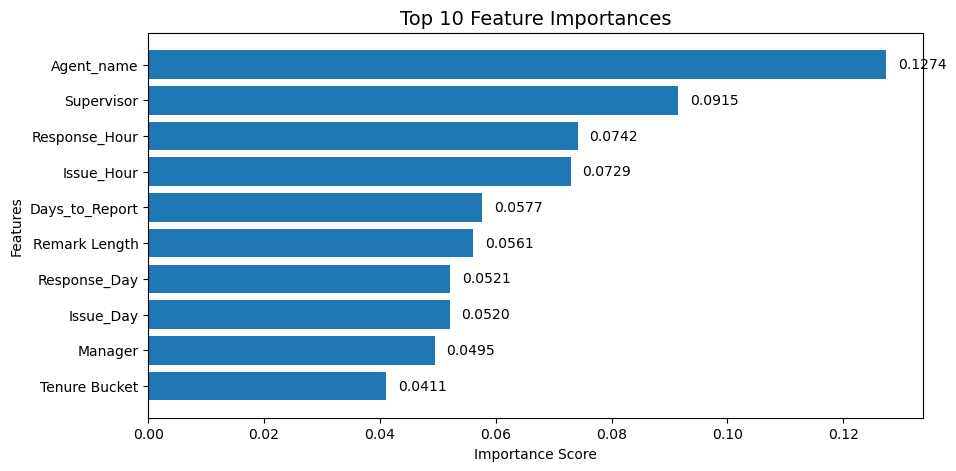

In [140]:
top10 = feature_importance.head(10)
plt.figure(figsize=(10,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.gca().invert_yaxis() 
plt.title('Top 10 Feature Importances', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
# Show importance values on bars
for index, value in enumerate(top10['Importance']):
    plt.text(value + 0.002, index, f'{value:.4f}', va='center')

plt.show()